<a href="https://colab.research.google.com/github/aj4di/AI-ComputerVision/blob/main/Siamese_Network_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Siamese Network Training**

In training a Siamese network, the network is presented with **pairs of similar and dissimilar inputs**, and **the network is trained to produce a high similarity score for similar inputs and a low similarity score for dissimilar inputs.**

## **The MNIST dataset**


The MNIST dataset is a dataset of handwritten digits, containing 60,000 training images and 10,000 test images. Each image is a 28x28 grayscale image, and each image is labeled with the corresponding digit that it represents. The MNIST dataset is a widely used dataset for training and testing image recognition models, particularly for models that are designed to recognize handwritten digits.

It is considered the "Hello World" dataset of Deep Learning and Computer Vision.



**MNIST** is an acronym that stands for the Modified National Institute of Standards and Technology dataset.

It is a dataset of 60,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9.


## **Importing the libraries**

In [ ]:

import numpy as np               # used for numerical computations in python and provides a powerful N-dimensional array object

import matplotlib.pyplot as plt  # used for creating static, animated, and interactive visualizations in Python

import tensorflow as tf          # used here to load the MNIST dataset and create and train the Siamese network

import itertools
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, GlobalAveragePooling2D, Dense, Reshape
                                  # These are TensorFlow Keras libraries that are used to create different layers in the Siamese network.
                                  # Input is used to create an input layer
                                  # Conv2D is used to create convolutional layers
                                  # BatchNormalization is used to normalize the activations of the previous layer
                                  # ReLU is used to apply ReLU activation function,

from tensorflow.keras.models import Sequential, Model  # Sequential is used to create a linear stack of layers


## **Loading the dataset and seeing the shape of the dataset**

In [ ]:


mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) =mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

11490434/11490434 [==============================] - 2s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

We can see that there are 60,000 examples in the training dataset and 10,000 in the test dataset.

The images are indeed square with 28×28 pixels.

## **Plotting the first few images of our dataset**

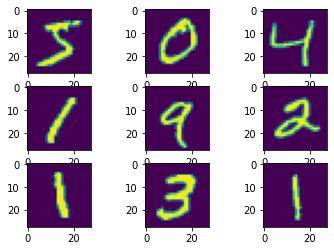

In [ ]:
for i in range(9):
 # define subplot
 plt.subplot(330 + 1 + i)
 # plot raw pixel data
 plt.imshow(X_train[i])
# show the figure
plt.show()

## **Creating the Siamese architecture**

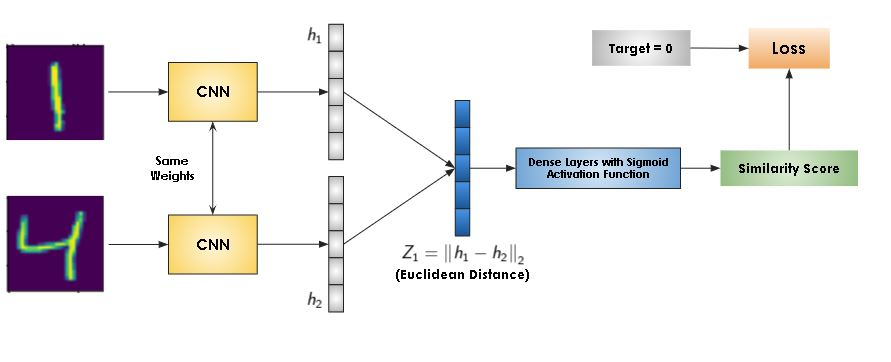

## **Creating the input images**

In [ ]:
img_A_inp = Input((28,28), name = "imga_A_input") # creates an input layer called "img_A_inp" with the shape of (28,28) and the name "imga_A_input"
img_B_inp = Input((28,28), name = "imga_B_input") # creates another input layer called "img_B_inp" with the same shape of (28,28) and the name "imga_B_input"

The input images are fed to the CNN block - let us create our CNN block.

The first step in the Siamese Network is Feature Extraction using CNNs. So the image will be passed through the convolutional neural network, which has a series of convolutional and pooling layers and a flatten layer at the end.

The CNN can be built according to the complexity of the problem. We can also use the classical CNN architecture such as VGG, ResNet and Inception Net etc.

The pre-trained CNN can also be used for feature extraction.
The output of this CNN will in fact be an n-dimensional feature vector.

## **Creating the CNN block**

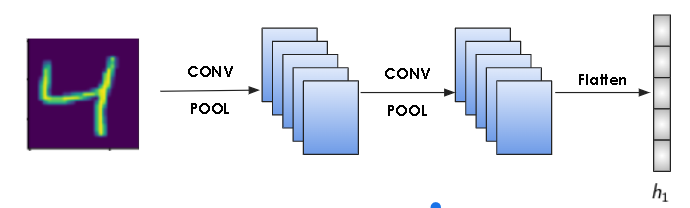

In [ ]:
def get_cnn_block(depth):
  # A function that returns a Sequential model with a Conv2D layer, a BatchNormalization layer and a ReLU activation
  return Sequential([Conv2D(depth, 3, 1), BatchNormalization(), ReLU()])

Depth = 64    # Setting the depth of CNN layer


# Create a sequential model with multiple CNN blocks, reshape layer, GlobalAveragePooling2D and a Dense layer


cnn = Sequential([Reshape((28,28,1), input_shape=(28, 28)),get_cnn_block(Depth),
                  get_cnn_block(Depth*2),
                  get_cnn_block(Depth*4),
                  get_cnn_block(Depth*8),
                  GlobalAveragePooling2D(),
                  Dense(64, activation ="relu")])



In [ ]:
# The input image A and B is passed through this cnn model and the output feature vectors are stored in
# feature_vector_A and feature_vector_B
feature_vector_A = cnn(img_A_inp)
feature_vector_B = cnn(img_B_inp)

In [ ]:
# concatenate the feature vectors A and B to create a single feature vector
concat = tf.keras.layers.Concatenate()([feature_vector_A, feature_vector_B])

# create a fully connected dense layer with 64 neurons and relu activation function.
dense = Dense(64, activation = "relu")(concat)

# create output layer with output layer with 1 neuron and sigmoid activation function.
output =  Dense(1, activation = "sigmoid")(dense)

model = Model(inputs= [img_A_inp, img_B_inp], outputs = output)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 imga_A_input (InputLayer)      [(None, 28, 28)]     0           []                               
                                                                                                  
 imga_B_input (InputLayer)      [(None, 28, 28)]     0           []                               
                                                                                                  
 sequential_4 (Sequential)      (None, 64)           1586496     ['imga_A_input[0][0]',           
                                                                  'imga_B_input[0][0]']           
                                                                                                  
 concatenate (Concatenate)      (None, 128)          0           ['sequential_4[0][0]',       

## **Generating Positive and Negative images**

Let us create a smaller sample of data for training and testing purposes before we use the entire dataset.

In [ ]:
# generates a random sample of 300 indices from the range of 0 to the number of training samples in the X_train set
random_indices = np.random.choice(X_train.shape[0], 300, replace = False)

# select a random sample of 300 examples from the X_train and y_train datasets respectively
X_train_sample, y_train_sample =X_train[random_indices], y_train[random_indices]

X_train_sample.shape, y_train_sample.shape

((300, 28, 28), (300,))

- X_train_sample dataset has 300 samples, each sample has a shape of (28, 28) and y_train_sample has 300 samples, each sample is a one-dimensional vector

Let us create a function to create a dataset out of this for training a Siamese Network - where you need to compare two images and predict whether they are similar or not.


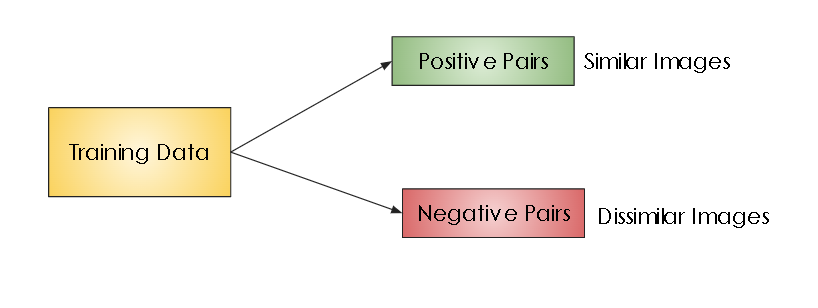

## **Generating Positive Pairs**
The positive samples have the images which are of the same class.

These help the model learn which of the images are similar. The positive samples can be generated as follows:

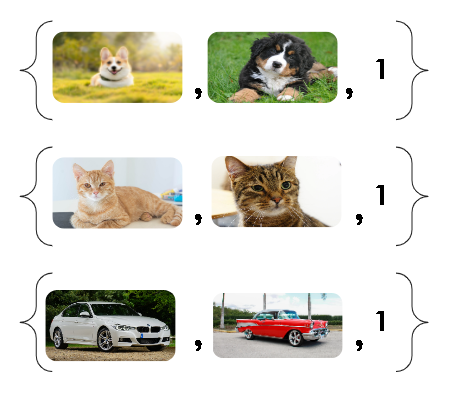

## **Generating Negative Pairs**

The negative samples have images which are from different classes.

The negative samples can be generated as follows:

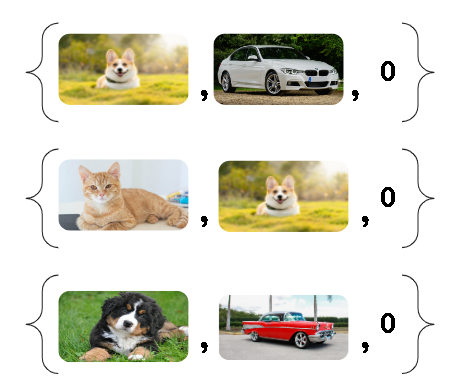

In [ ]:


def mark_paired_datasets(X,y):
  X_pairs, y_pairs =[], []                   # create 2 empty lists X_pairs and y_pairs

  tuples =[(x1,y1) for x1, y1 in zip(X,y)]   # creates a list of tuples where each tuple contains one image and its corresponding label from the input X and y datasets
  print (len(tuples))                        # line prints number of tuples

  for t in itertools.product(tuples, tuples): # create all possible pair of images from tuples list
    pair_A,pair_B = t                         # unpacks each pair of tuples, (img_A, label_A) and (img_B, label_B) from the iterator
    img_A,label_A = pair_A
    img_B,label_B = pair_B
    new_label = int (label_A==label_B)       # a new label, if the labels of both images are equal then the new_label is 1 otherwise 0.
    X_pairs.append([img_A,img_B])
    y_pairs.append(new_label)

  X_pairs = np.array(X_pairs)
  y_pairs = np.array(y_pairs)               # convert X_pairs and y_pairs to numpy arrays

  return X_pairs, y_pairs

In [ ]:
# this code is calling the mark_paired_datasets function on the X_train_sample, y_train_sample and X_test_sample, y_test_sample datasets, creating new pairs of images and their labels,
# and printing the shape of newly created datasets
# This new dataset will be used to train the siamese network.

mark_paired_datasets(X_train_sample, y_train_sample)
X_train_pairs, y_train_pairs = mark_paired_datasets(X_train_sample, y_train_sample)
X_train_pairs.shape
y_train_pairs.shape

300
300


(90000,)

In [ ]:
random_indices = np.random.choice(X_test.shape[0], 150, replace = False)

X_test_sample, y_test_sample =X_test[random_indices], y_test[random_indices]

X_test_sample.shape, y_test_sample.shape


X_test_pairs, y_test_pairs = mark_paired_datasets(X_test_sample, y_test_sample)
X_test_pairs.shape, y_test_pairs.shape

150


((22500, 2, 28, 28), (22500,))

## **Compiling and training the model**

In [ ]:

model.compile(loss=tf.keras.losses.BinaryCrossentropy(), optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
              metrics =['accuracy'])

model.fit([X_train_pairs[:, 0], X_train_pairs[:, 1]], y_train_pairs, batch_size=64, epochs=5,
          validation_data=([X_test_pairs[:, 0], X_test_pairs[:, 1]], y_test_pairs))

# [X_train_pairs[:, 0], X_train_pairs[:, 1]]: This is the training data for the model.
# In this case, the training data is passed as a list of two numpy arrays, where the first array is the first image of the pairs and
# the second array is the second image of the pairs
# This is because the input of the model is two images, and they are passed as two different arrays.
# y_train_pairs: This is the training labels for the model.
# The labels are binary values, indicating whether the two images in the pair are of the same class or not.


Epoch 1/5
1407/1407 [==============================] - 140s 88ms/step - loss: 0.2138 - accuracy: 0.9221 - val_loss: 0.2039 - val_accuracy: 0.9296
Epoch 2/5
1407/1407 [==============================] - 122s 87ms/step - loss: 0.0501 - accuracy: 0.9801 - val_loss: 0.2173 - val_accuracy: 0.9408
Epoch 3/5
1407/1407 [==============================] - 123s 87ms/step - loss: 0.0149 - accuracy: 0.9949 - val_loss: 0.2488 - val_accuracy: 0.9438
Epoch 4/5
1407/1407 [==============================] - 123s 87ms/step - loss: 0.0070 - accuracy: 0.9977 - val_loss: 0.2687 - val_accuracy: 0.9410
Epoch 5/5
1407/1407 [==============================] - 120s 85ms/step - loss: 0.0050 - accuracy: 0.9983 - val_loss: 0.2737 - val_accuracy: 0.9490


## **Making Predictions**

In [ ]:
img_A, img_B = X_test[0], X_test[9]

label_A, label_B = y_test[0], y_test[9]

label_A, label_B

(7, 9)

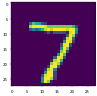

In [ ]:
import matplotlib.pyplot as plt
plt.figure(dpi = 28)
plt.imshow(img_A)


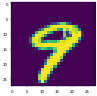

In [ ]:
plt.figure(dpi = 28)
plt.imshow(img_B)

In [ ]:
model.predict([img_A.reshape((1,28,28)), img_B.reshape((1,28,28))]).flatten()

1/1 [==============================] - 0s 498ms/step


array([3.3881342e-12], dtype=float32)

In [ ]:
img_A, img_B = X_test[0], X_test[17]

label_A, label_B = y_test[0], y_test[17]

label_A, label_B

(7, 7)

In [ ]:
model.predict([img_A.reshape((1,28,28)), img_B.reshape((1,28,28))]).flatten()

1/1 [==============================] - 0s 22ms/step


array([1.], dtype=float32)

In [ ]:
img_A, img_B = X_test[11], X_test[123]

label_A, label_B = y_test[11], y_test[123]

label_A, label_B

(6, 6)

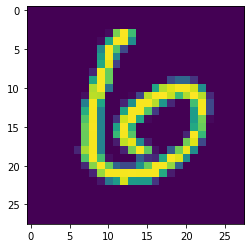

In [ ]:
plt.imshow(img_A)

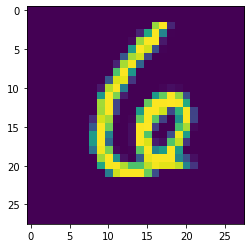

In [ ]:
plt.imshow(img_B)

In [ ]:
model.predict([img_A.reshape((1,28,28)), img_B.reshape((1,28,28))]).flatten()

1/1 [==============================] - 0s 26ms/step


array([0.11159036], dtype=float32)

## **The Contrastive Loss Function**

The contrastive loss is given by the equation:

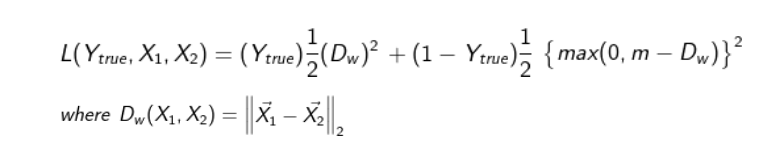

- Where Y is the data's true label, indicating whether the two given images (X1 and X2) are similar (Y=0) or dissimilar (Y=1).
The Dw term denotes the similarity of two feature vectors.

- Dw is a Euclidean distance. We can, however, utilize other similarity measurements such as Manhattan distance, Cosine similarity, and so on.

The goal of the contrastive loss function is to have a small distance for positive pairs and a larger distance between negative pairs.

We need the embeddings of images of the same class to be very close and embeddings of images of different classes to be very far apart.

In [ ]:
from tensorflow.keras import backend as K

def contrastive_loss(y_true, y_pred):
  y_true = K.cast(y_true, 'float32')
  margin = 1
  y_pred = K.concatenate([y_pred[0], y_pred[1]], axis=-1)
  square_pred = K.square(y_pred)
  margin_square = K.square(K.maximum(margin - y_pred, 0))
  return K.mean(y_true * square_pred + (1 - y_true) * margin_square)



We define a custom contrastive loss function - "contrastive_loss" which takes y_true and y_pred as input. This function uses the formula for contrastive loss which is :
loss = y * d^2 + (1-y) * max(m - d, 0)^2

where y is 1 if the images are of the same class, and 0 otherwise, d is the euclidean distance between the feature vectors of the two images and m is the margin hyperparameter.

Then we pass this contrastive_loss function to the model.compile function to use as the loss function for the model.

In [ ]:
model.compile(optimizer='Adam', loss=contrastive_loss, metrics=['accuracy'])
model.fit([X_train_pairs[:, 0], X_train_pairs[:, 1]], y_train_pairs, batch_size=64, epochs=5,
          validation_data=([X_test_pairs[:, 0], X_test_pairs[:, 1]], y_test_pairs))


Epoch 1/5
1407/1407 [==============================] - 120s 83ms/step - loss: 0.1181 - accuracy: 0.1235 - val_loss: 0.1043 - val_accuracy: 0.1043
Epoch 2/5
1407/1407 [==============================] - 113s 81ms/step - loss: 0.1031 - accuracy: 0.1031 - val_loss: 0.1043 - val_accuracy: 0.1043
Epoch 3/5
1407/1407 [==============================] - 115s 82ms/step - loss: 0.1031 - accuracy: 0.1031 - val_loss: 0.1043 - val_accuracy: 0.1043
Epoch 4/5
1407/1407 [==============================] - 113s 81ms/step - loss: 0.1031 - accuracy: 0.1031 - val_loss: 0.1043 - val_accuracy: 0.1043
Epoch 5/5
1407/1407 [==============================] - 113s 80ms/step - loss: 0.1045 - accuracy: 0.1044 - val_loss: 0.1043 - val_accuracy: 0.1043


**Loss**: The loss value is around 0.09. This is the value of the contrastive loss function. It's a measure of how well the model is able to distinguish between the different classes. A lower loss value generally indicates that the model is performing better.

**Accuracy**: The accuracy is around 0.10, which is very low. This indicates that the model is not performing well in terms of accuracy, it is not able to predict whether the two images in the pair are of the same class or not.

**Validation loss and accuracy**: The validation loss and accuracy are also low, and similar to the training loss and accuracy. This indicates that the model is not generalizing well to unseen data.

**Convergence**: From the output, we can see that the loss value is not changing significantly after the first epoch and the accuracy is not changing at all. This indicates that the model is not learning or converging to a good solution.

**Overfitting:** The model is not overfitting as the training accuracy and validation accuracy are similar.